In [1]:
"""
===========================================================
Multi-Hop Quantum Controlled Teleportation (MQCT)
Paper-Reproduction Correct Qiskit Implementation

Implements:
- m-hop teleportation
- Depolarizing noise channel Eq.(17) using Aer NoiseModel
- Fidelity Eq.(19)
- Avg Fidelity Eq.(20)
- Fig.5 + Fig.6 style plots
===========================================================
"""

import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, state_fidelity

from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error


In [2]:
# ============================================================
# 1. Input State
# ============================================================

def prepare_input_state(qc, qubit, theta, phi):
    qc.ry(2 * theta, qubit)
    qc.rz(phi, qubit)


# ============================================================
# 2. GHZ Channel + Inverse Transform
# ============================================================

def create_ghz_state(qc, qubits):
    q0, q1, q2 = qubits
    qc.h(q0)
    qc.cx(q0, q1)
    qc.cx(q1, q2)


def inverse_ghz_transform(qc, qubits):
    q0, q1, q2 = qubits
    qc.cx(q1, q2)
    qc.cx(q0, q1)
    qc.h(q0)

In [3]:
# ============================================================
# 3. Build m-Hop MQCT Circuit
# ============================================================

def build_m_hop_mqct(m_hops, theta, phi):

    total_qubits = 3 * m_hops + 1
    total_clbits = 2 * m_hops

    qr = QuantumRegister(total_qubits, "q")
    cr = ClassicalRegister(total_clbits, "c")

    qc = QuantumCircuit(qr, cr)

    alice = 0
    sender = alice

    qc.barrier(label="Input")
    prepare_input_state(qc, alice, theta, phi)

    for hop in range(m_hops):

        qc.barrier(label=f"Hop {hop+1}")

        base = 1 + 3 * hop
        charlie = base
        intermediate = base + 1
        receiver = base + 2

        # GHZ Channel
        create_ghz_state(qc, [charlie, intermediate, receiver])

        # Inverse GHZ Transform
        inverse_ghz_transform(qc, [sender, charlie, intermediate])

        # Measurements
        qc.measure(sender, 2 * hop)
        qc.measure(charlie, 2 * hop + 1)

        # Corrections
        with qc.if_test((cr[2 * hop], 1)):
            qc.z(receiver)

        with qc.if_test((cr[2 * hop + 1], 1)):
            qc.x(receiver)

        sender = receiver

    return qc

In [10]:
from qiskit_aer.noise import (
    NoiseModel,
    depolarizing_error,
    pauli_error,
    amplitude_damping_error,
    phase_damping_error
)

def build_noise_model(p, mode):
    """
    Build one independent noise model (NO mixing).

    Modes:
    - depolarizing
    - dephasing
    - bitflip
    - phaseflip
    - amplitude_damping
    - phase_damping
    """

    noise_model = NoiseModel()

    # ---------------------------------------------------
    # (1) Depolarizing channel (2-qubit) Eq.(17)
    # ---------------------------------------------------
    if mode == "depolarizing":
        err2 = depolarizing_error(p, 2)
        noise_model.add_all_qubit_quantum_error(err2, ["cx"])

    # ---------------------------------------------------
    # (2) Dephasing channel Eq.(18)
    # ---------------------------------------------------
    elif mode == "dephasing":
        err1 = pauli_error([("I", 1-p), ("Z", p)])
        err2 = err1.tensor(err1)
        noise_model.add_all_qubit_quantum_error(err2, ["cx"])

    # ---------------------------------------------------
    # (3) Bit-flip noise Eq.(13)
    # ---------------------------------------------------
    elif mode == "bitflip":
        err1 = pauli_error([("I", 1-p), ("X", p)])
        noise_model.add_all_qubit_quantum_error(err1, ["x", "h", "ry", "rz"])

    # ---------------------------------------------------
    # (4) Phase-flip noise Eq.(14)
    # ---------------------------------------------------
    elif mode == "phaseflip":
        err1 = pauli_error([("I", 1-p), ("Z", p)])
        noise_model.add_all_qubit_quantum_error(err1, ["x", "h", "ry", "rz"])

    # ---------------------------------------------------
    # (5) Amplitude damping Eq.(15)
    # ---------------------------------------------------
    elif mode == "amplitude_damping":
        err1 = amplitude_damping_error(p)
        noise_model.add_all_qubit_quantum_error(err1, ["x", "h", "ry"])

    # ---------------------------------------------------
    # (6) Phase damping Eq.(16)
    # ---------------------------------------------------
    elif mode == "phase_damping":
        err1 = phase_damping_error(p)
        noise_model.add_all_qubit_quantum_error(err1, ["x", "h", "ry"])

    return noise_model


In [12]:
# ============================================================
# 5. Fidelity Simulation Eq.(19)
# ============================================================

from qiskit.quantum_info import DensityMatrix, partial_trace, state_fidelity
from qiskit_aer import AerSimulator

def simulate_fidelity_one_noise(m_hops, theta, phi, noise_p, noise_mode, shots=100):

    qc = build_m_hop_mqct(m_hops, theta, phi)
    qc.save_statevector()

    noise_model = build_noise_model(noise_p, noise_mode)

    sim = AerSimulator(
        method="statevector",
        noise_model=noise_model
    )

    fidelities = []

    total_qubits = 3*m_hops + 1
    bob_index = total_qubits - 1
    traced_out = [i for i in range(total_qubits) if i != bob_index]

    for _ in range(shots):
        result = sim.run(qc).result()
        state = result.get_statevector()

        rho = DensityMatrix(state)
        rho_bob = partial_trace(rho, traced_out)

        target = Statevector([
            np.cos(theta),
            np.exp(1j*phi)*np.sin(theta)
        ])

        fidelities.append(state_fidelity(rho_bob, target))

    return np.mean(fidelities)



# ============================================================
# 6. Average Fidelity Eq.(20)
# ============================================================

def average_fidelity(m_hops, noise_p=0.05, samples=8):

    theta_vals = np.linspace(0, np.pi, samples)
    phi_vals = np.linspace(0, 2*np.pi, samples)

    fidelities = []

    for theta in theta_vals:
        for phi in phi_vals:
            fidelities.append(simulate_fidelity_one_noise(m_hops, theta, phi, noise_p))

    return np.mean(fidelities)



RUNNING FULL MQCT NOISE REPRODUCTION
Noise Channels: 6 types × hops m=1–3 × p ∈ [0,0.5]

MQCT FULL NOISE REPRODUCTION (6 Channels)

######################################################################
HOP COUNT m = 1
######################################################################

Noise strength p = 0.00
  depolarizing       Fidelity = 1.0000
  dephasing          Fidelity = 1.0000
  bitflip            Fidelity = 1.0000
  phaseflip          Fidelity = 1.0000
  amplitude_damping  Fidelity = 1.0000
  phase_damping      Fidelity = 1.0000
  Runtime = 9.87 sec

Noise strength p = 0.10
  depolarizing       Fidelity = 0.8387
  dephasing          Fidelity = 0.8200
  bitflip            Fidelity = 0.8063
  phaseflip          Fidelity = 0.8650
  amplitude_damping  Fidelity = 0.8580
  phase_damping      Fidelity = 0.9550
  Runtime = 55.72 sec

Noise strength p = 0.20
  depolarizing       Fidelity = 0.6700
  dephasing          Fidelity = 0.6775
  bitflip            Fidelity = 0.7113
  phas

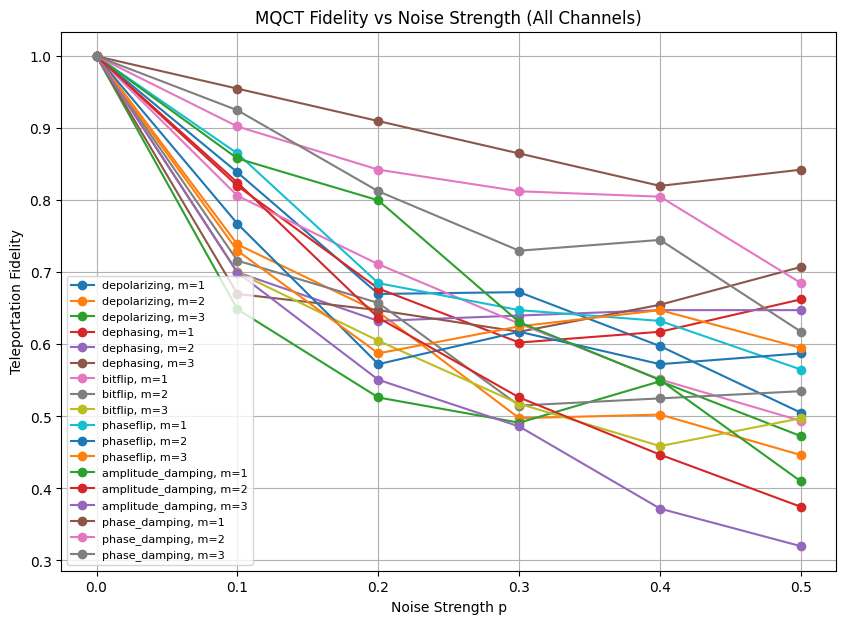

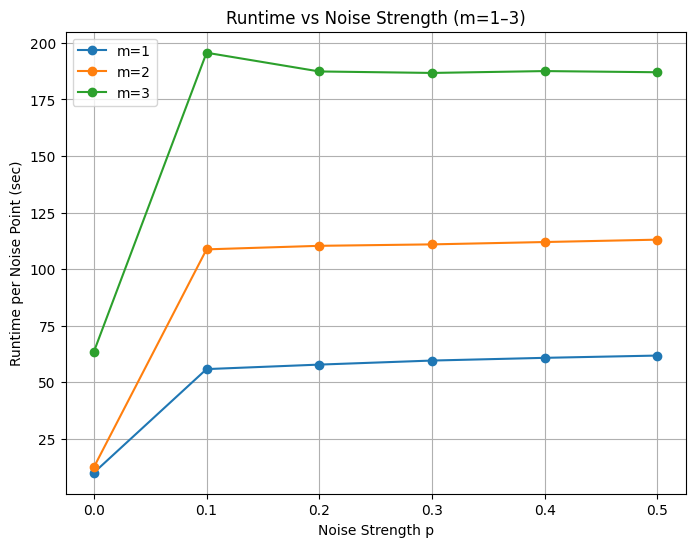

In [13]:
# ============================================================
# 7. FIGURE 5: Avg Fidelity vs Hops
# ============================================================

import time

import time

def sweep_all_noise_channels(max_hops=3, noise_points=6, shots=100):

    noise_vals = np.linspace(0, 0.5, noise_points)

    noise_types = [
        "depolarizing",
        "dephasing",
        "bitflip",
        "phaseflip",
        "amplitude_damping",
        "phase_damping"
    ]

    results = {
        noise: {m: [] for m in range(1, max_hops+1)}
        for noise in noise_types
    }

    runtime = {m: [] for m in range(1, max_hops+1)}

    print("\n" + "="*80)
    print("MQCT FULL NOISE REPRODUCTION (6 Channels)")
    print("="*80)

    for m in range(1, max_hops+1):

        print("\n" + "#"*70)
        print(f"HOP COUNT m = {m}")
        print("#"*70)

        for p in noise_vals:

            print(f"\nNoise strength p = {p:.2f}")
            start = time.time()

            for noise_mode in noise_types:

                fid = simulate_fidelity_one_noise(
                    m_hops=m,
                    theta=np.pi/3,
                    phi=np.pi/4,
                    noise_p=p,
                    noise_mode=noise_mode,
                    shots=shots
                )

                results[noise_mode][m].append(fid)

                print(f"  {noise_mode:<18} Fidelity = {fid:.4f}")

            runtime[m].append(time.time() - start)

            print(f"  Runtime = {runtime[m][-1]:.2f} sec")

    return noise_vals, results, runtime


def plot_all_noise_curves(noise_vals, results):

    plt.figure(figsize=(10,7))

    for noise_mode in results:

        for m in results[noise_mode]:

            plt.plot(
                noise_vals,
                results[noise_mode][m],
                marker="o",
                label=f"{noise_mode}, m={m}"
            )

    plt.xlabel("Noise Strength p")
    plt.ylabel("Teleportation Fidelity")
    plt.title("MQCT Fidelity vs Noise Strength (All Channels)")
    plt.grid(True)
    plt.legend(fontsize=8)

    plt.savefig("all_noise_channels.png", dpi=300)
    print("Saved: all_noise_channels.png")



# ============================================================
# MAIN
# ============================================================


if __name__ == "__main__":

    # -----------------------------
    # Simulation Parameters
    # -----------------------------
    max_hops     = 3        # Only simulate up to m=3 (avoids memory blowup)
    noise_points = 6        # p values from 0.0 → 0.5
    shots        = 100      # Monte Carlo samples per point

    print("\n" + "="*80)
    print("RUNNING FULL MQCT NOISE REPRODUCTION")
    print("Noise Channels: 6 types × hops m=1–3 × p ∈ [0,0.5]")
    print("="*80)

    # -----------------------------
    # Run Sweep
    # -----------------------------
    noise_vals, results, runtime = sweep_all_noise_channels(
        max_hops=max_hops,
        noise_points=noise_points,
        shots=shots
    )

    # -----------------------------
    # Plot Fidelity Curves
    # -----------------------------
    plot_all_noise_curves(noise_vals, results)

    # -----------------------------
    # Plot Runtime Curves
    # -----------------------------
    plt.figure(figsize=(8,6))

    for m in runtime:
        plt.plot(
            noise_vals,
            runtime[m],
            marker="o",
            label=f"m={m}"
        )

    plt.xlabel("Noise Strength p")
    plt.ylabel("Runtime per Noise Point (sec)")
    plt.title("Runtime vs Noise Strength (m=1–3)")
    plt.grid(True)
    plt.legend()

    plt.savefig("runtime_all_channels.png", dpi=300)
    print("Saved: runtime_all_channels.png")

    # -----------------------------
    # Done
    # -----------------------------
    print("\n" + "="*80)
    print("SIMULATION COMPLETE")
    print("Generated Figures:")
    print("  • all_noise_channels.png")
    print("  • runtime_all_channels.png")
    print("="*80)



Saved: depolarizing_only.png
Saved: dephasing_only.png


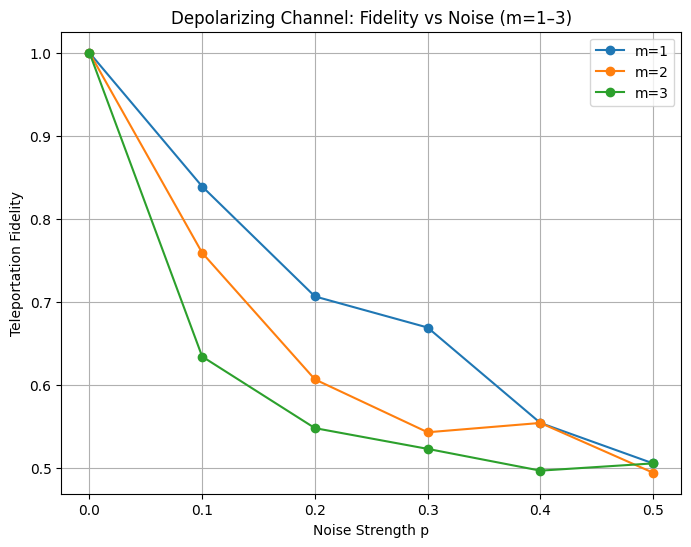

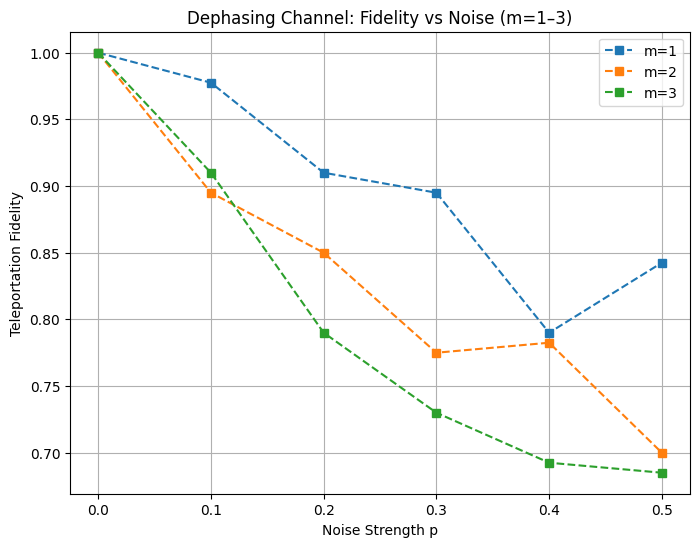

In [8]:
def plot_depolarizing_only(noise_vals, results):

    plt.figure(figsize=(8,6))

    for m in results["depolarizing"]:
        plt.plot(
            noise_vals,
            results["depolarizing"][m],
            marker="o",
            label=f"m={m}"
        )

    plt.xlabel("Noise Strength p")
    plt.ylabel("Teleportation Fidelity")
    plt.title("Depolarizing Channel: Fidelity vs Noise (m=1–3)")
    plt.grid(True)
    plt.legend()

    plt.savefig("depolarizing_only.png", dpi=300)
    print("Saved: depolarizing_only.png")

plot_depolarizing_only(noise_vals, results)

def plot_dephasing_only(noise_vals, results):

    plt.figure(figsize=(8,6))

    for m in results["dephasing"]:
        plt.plot(
            noise_vals,
            results["dephasing"][m],
            marker="s",
            linestyle="--",
            label=f"m={m}"
        )

    plt.xlabel("Noise Strength p")
    plt.ylabel("Teleportation Fidelity")
    plt.title("Dephasing Channel: Fidelity vs Noise (m=1–3)")
    plt.grid(True)
    plt.legend()

    plt.savefig("dephasing_only.png", dpi=300)
    print("Saved: dephasing_only.png")

plot_dephasing_only(noise_vals, results)


Saved: depolarizing_fidelity.png
Saved: dephasing_fidelity.png
Saved: bitflip_fidelity.png
Saved: phaseflip_fidelity.png
Saved: amplitude_damping_fidelity.png
Saved: phase_damping_fidelity.png


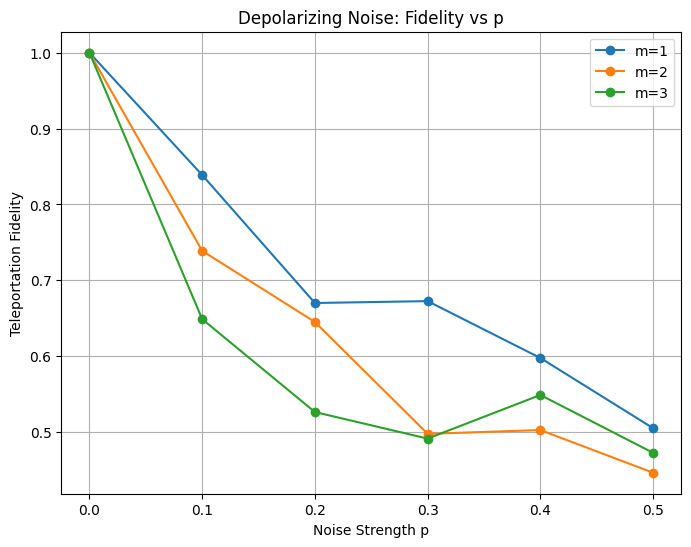

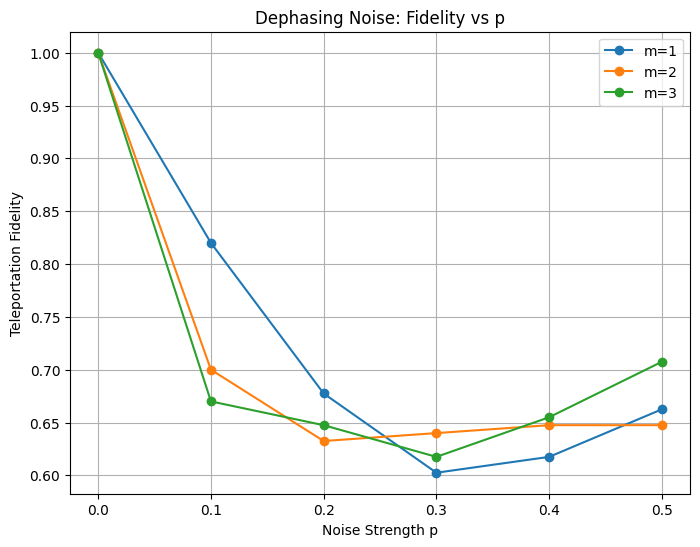

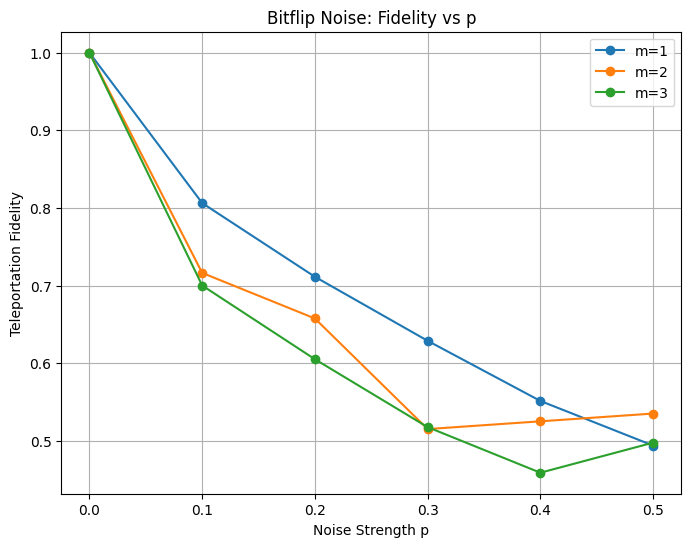

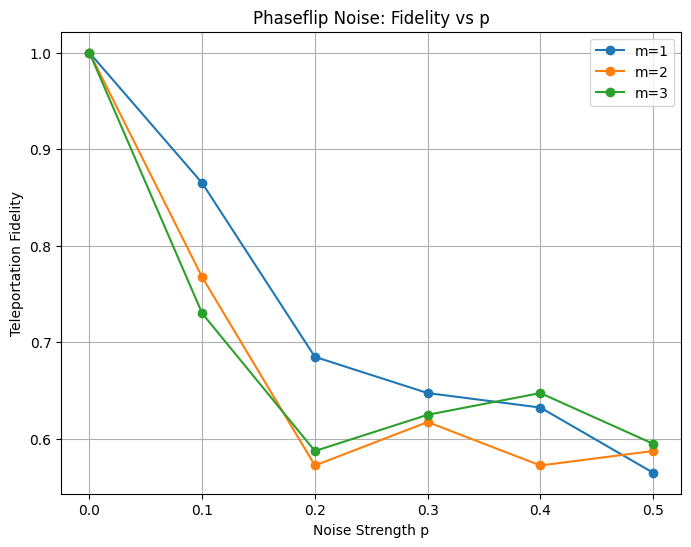

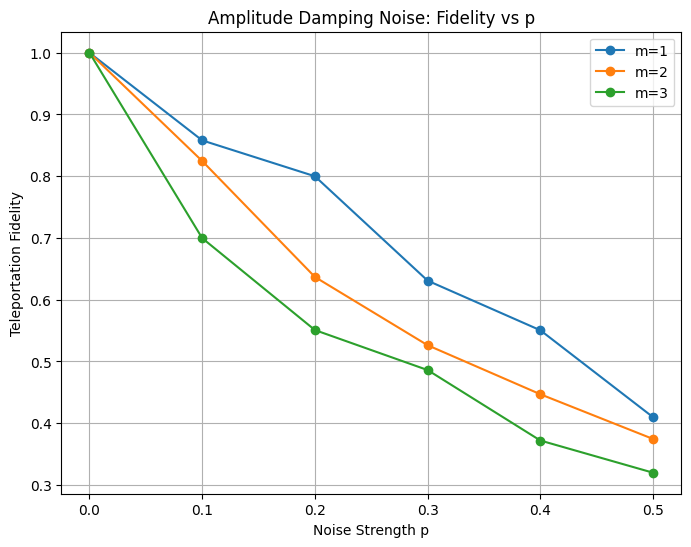

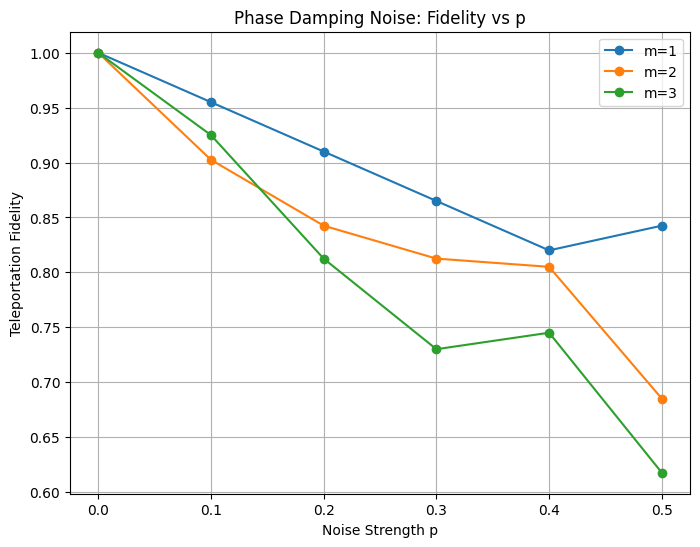

In [14]:
def plot_each_noise_channel_separately(noise_vals, results):

    for noise_mode in results:

        plt.figure(figsize=(8,6))

        # Plot m=1,2,3 for this noise only
        for m in results[noise_mode]:
            plt.plot(
                noise_vals,
                results[noise_mode][m],
                marker="o",
                label=f"m={m}"
            )

        plt.xlabel("Noise Strength p")
        plt.ylabel("Teleportation Fidelity")
        plt.title(f"{noise_mode.replace('_',' ').title()} Noise: Fidelity vs p")
        plt.grid(True)
        plt.legend()

        filename = f"{noise_mode}_fidelity.png"
        plt.savefig(filename, dpi=300)

        print(f"Saved: {filename}")

plot_each_noise_channel_separately(noise_vals, results)